#### Tissera Ana Paula - `Notebook TP3`

In [1]:
%load_ext autoreload
%autoreload 2

##### Imports

In [ ]:
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
import cupy as cp

In [ ]:
# uso de cupy en vez de numpy para correrlo en GPU

import cupy as cp

device_id = cp.cuda.Device().id
device_name = cp.cuda.runtime.getDeviceProperties(device_id)['name']

print(f"Usando GPU {device_id}: {device_name}")

Usando GPU 0: b'NVIDIA GeForce RTX 3050 Laptop GPU'


In [4]:
SEED = 42

### `1.` **Análisis y Preprocesamiento de Datos**

In [5]:
X_images = cp.load("data/X_images.npy")
y_images = cp.load("data/y_images.npy")

In [6]:
print("Forma de X:", X_images.shape)
print("Forma de y:", y_images.shape)
print("Etiquetas únicas:", cp.unique(y_images))

Forma de X: (5000, 784)
Forma de y: (5000,)
Etiquetas únicas: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48]


### Visualización de imágenes

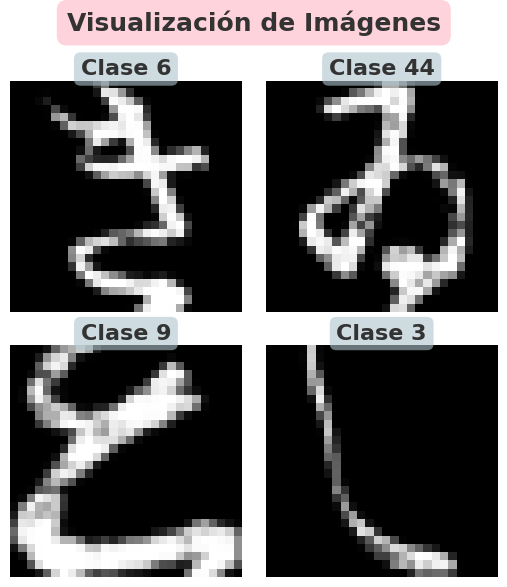

In [7]:
from src.plot import plot_images

name_map = {int(i): f"Clase {int(i)}" for i in cp.unique(y_images)}

cp.random.seed(SEED)
clases = cp.unique(y_images)
clases_seleccion = cp.random.choice(clases, size=4, replace=False)
indices = []
for cl in clases_seleccion:
    idxs_cl = cp.where(y_images == cl)[0]
    idx = int(cp.random.choice(idxs_cl, size=1)[0])
    indices.append(idx)

plot_images(X_images, y_images, indices=indices, n_cols=2, suptitle="Visualización de Imágenes", name_map=name_map, random_seed=SEED)

In [9]:
print("X:", type(X_images), "shape =", X_images.shape, "dtype =", X_images.dtype)
print("y:", type(y_images), "shape =", y_images.shape, "dtype =", y_images.dtype)

print("X min/max:", X_images.min(), "/", X_images.max())

X: <class 'cupy.ndarray'> shape = (5000, 784) dtype = float32
y: <class 'cupy.ndarray'> shape = (5000,) dtype = int64
X min/max: 0.0 / 255.0


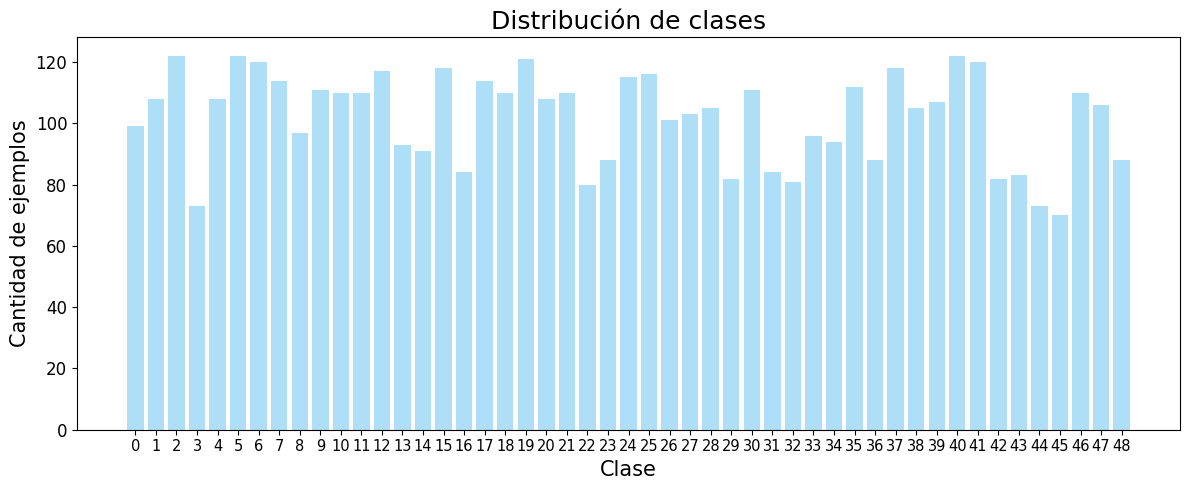

In [10]:
from src.plot import plot_class_distribution
plot_class_distribution(y_images, name_map=name_map, figsize=(12, 5), color='#AEDFF7')

In [11]:
print("Media de píxeles en todo X:", X_images.mean())
print("Desviación estándar de píxeles:", X_images.std())

Media de píxeles en todo X: 46.525505
Desviación estándar de píxeles: 87.5637


#### División del dataset


In [ ]:
from src.data_splitting import split_data

X_dev, y_dev, X_test, y_test = split_data(X_images, y_images, ratio=0.2, seed=SEED)
X_train, y_train, X_val, y_val = split_data(X_dev, y_dev, ratio=0.2, seed=SEED)

#### Normalización

In [13]:
# Normalización y conversión de tipo
X_train = X_train.astype(cp.float32) / 255.0
X_val   = X_val.astype(cp.float32)   / 255.0
X_test  = X_test.astype(cp.float32)  / 255.0
X_dev   = X_dev.astype(cp.float32)   / 255.0

# # Guardar procesados
# out_dir = "data/processed"
# os.makedirs(out_dir, exist_ok=True)
# cp.savez_compressed(os.path.join(out_dir, "train.npz"), X=X_train, y=y_train)
# cp.savez_compressed(os.path.join(out_dir, "val.npz"),   X=X_val,   y=y_val)
# cp.savez_compressed(os.path.join(out_dir, "test.npz"),  X=X_test,  y=y_test)


### `2.` **Implementación y Entrenamiento de una Red Neuronal Básica**

In [16]:
from src.Neural_Network import NeuralNetwork
from src.metrics import Metrics  

Red Neuronal con 2 capas ocultas, con 100 y 80 nodos

Epochs: 100%|██████████| 1000/1000 [00:29<00:00, 33.97it/s]


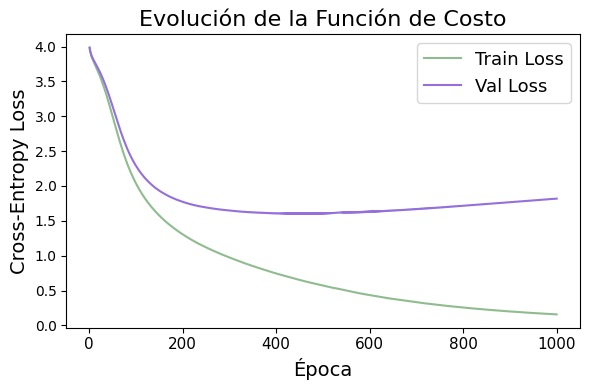

In [15]:
# Configuración y entrenamiento de la red
input_size    = X_train.shape[1]
hidden1, hidden2 = 100, 80
n_classes     = int(cp.max(y_train)) + 1
epochs        = 1000

# One-hot encoding
Y_train_oh = cp.eye(n_classes, dtype=cp.float32)[y_train]
Y_val_oh   = cp.eye(n_classes, dtype=cp.float32)[y_val]

M0 = NeuralNetwork(
    layer_sizes=[input_size, hidden1, hidden2, n_classes],
    learning_rate=0.1,
    seed=SEED
)

train_losses_M0, val_losses_M0 = M0.train_bp(
    X_train, Y_train_oh,
    X_val= X_val, Y_val=Y_val_oh,
    epochs=epochs,
    plot=True
)

### Métricas en Conjunto de Entrenamiento
**Accuracy:** **0.9947**  
**Cross-Entropy Loss:** 0.1153  


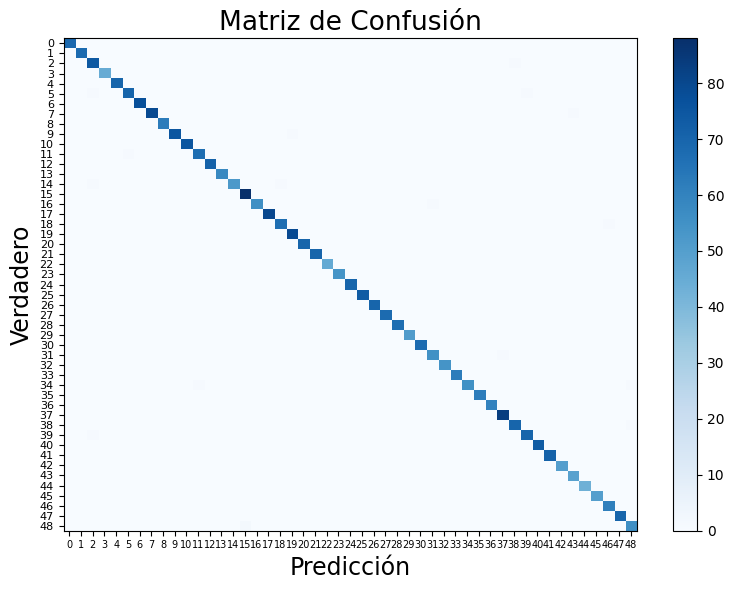

### Métricas en Conjunto de Validación
**Accuracy:** **0.6100**  
**Cross-Entropy Loss:** 1.8887  


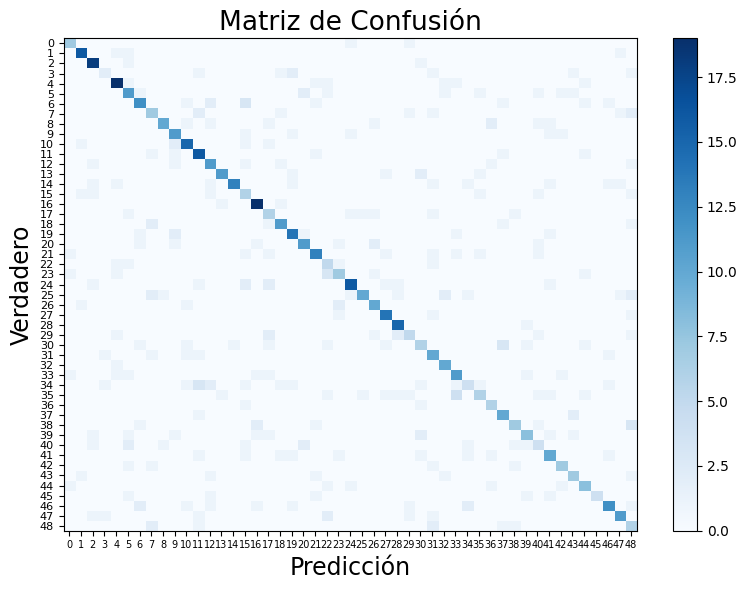

In [ ]:
Y_hat_train_M0 = M0.forward(X_train, train= False)
y_proba_train_M0 = Y_hat_train_M0.T
y_pred_train_M0  = cp.argmax(Y_hat_train_M0, axis=0)

Y_hat_val_M0   = M0.forward(X_val, train= False)
y_proba_val_M0 = Y_hat_val_M0.T
y_pred_val_M0  = cp.argmax(Y_hat_val_M0, axis=0)

met_train_M0 = Metrics(y_true=y_train, y_pred=y_pred_train_M0, y_proba=y_proba_train_M0)
met_train_M0.report_metrics(title="Métricas en Conjunto de Entrenamiento", show_matrix_table=False)

met_val_M0 = Metrics(y_true=y_val, y_pred=y_pred_val_M0, y_proba=y_proba_val_M0)
met_val_M0.report_metrics(title="Métricas en Conjunto de Validación")

### `3.` **Implementación y Entrenamiento de una Red Neuronal Avanzada**

3.1)

In [ ]:
epochs = 300

configs_optimizers = {
    'Batch GD':                 {'optimizer':'gd'},
    'Rate Scheduling Lineal':   {'lr_schedule':'linear', 'learning_rate':0.2},
    'Rate Scheduling Exp':      {'lr_schedule':'exp',    'learning_rate':0.5},
    'Mini-batch Stochastic GD': {'optimizer':'mb',       'batch_size':32,    'learning_rate':0.01},
    'Adam':                     {'optimizer':'adam',     'learning_rate':0.01},
    'L2 (λ=1e-1)':              {'l2_lambda':1e-1},
    'EarlyStop (p=5)':          {'early_stopping':True,  'patience':5},
    'Dropout (p=0.2)':          {'dropout_p':0.2},
    'BatchNorm':                {'use_batchnorm':True,   'learning_rate':0.02},
}

results_optimizers = []
all_train_losses_optimizers = {}
all_val_losses_optimizers   = {}

for name, params in configs_optimizers.items():
    nn = NeuralNetwork(
        layer_sizes=[input_size, hidden1, hidden2, n_classes],
        learning_rate=params.get('learning_rate', 0.1),
        seed=SEED,
        optimizer=params.get('optimizer', 'gd'),
        batch_size=params.get('batch_size', None),
        l2_lambda=params.get('l2_lambda', 0.0),
        dropout_p=params.get('dropout_p', 0.0),
        use_batchnorm=params.get('use_batchnorm', False),
        early_stopping=params.get('early_stopping', False),
        patience=params.get('patience', 5),
        lr_min = 0.001
    )

    lr_schedule = None
    if params.get('lr_schedule') == 'linear':
        lr_schedule = nn.get_linear_schedule(final_lr=0.01, max_epochs=epochs)
    elif params.get('lr_schedule') == 'exp':
        lr_schedule = nn.get_exponential_schedule(decay_rate=0.01, final_lr=0.001)

    train_losses, val_losses = nn.train_bp(
        X_train, Y_train_oh,
        X_val=X_val, Y_val=Y_val_oh,
        epochs=epochs,
        plot=False,
        lr_schedule=lr_schedule
    )
    all_train_losses_optimizers[name] = train_losses
    all_val_losses_optimizers[name]   = val_losses

    # Métricas en entrenamiento
    Yhat_tr   = nn.forward(X_train, train=False)
    ypred_tr  = cp.argmax(Yhat_tr, axis=0)
    yproba_tr = Yhat_tr.T
    m_tr      = Metrics(y_true=y_train, y_pred=ypred_tr, y_proba=yproba_tr)
    acc_tr    = m_tr.accuracy()
    ce_tr     = m_tr.cross_entropy()

    # Métricas en validación 
    Yhat_v   = nn.forward(X_val, train=False)
    ypred_v  = cp.argmax(Yhat_v, axis=0)
    yproba_v = Yhat_v.T
    m_v      = Metrics(y_true=y_val, y_pred=ypred_v, y_proba=yproba_v)
    acc_v    = m_v.accuracy()
    ce_v     = m_v.cross_entropy()

    results_optimizers.append((name, acc_tr, ce_tr, acc_v, ce_v))

header = "|Método|Acc Train|CE Train|Acc Val|CE Val|\n"
sep    = "|" + "---|"*5 + "\n"
rows   = "".join(f"|{n}|{at:.4f}|{ct:.4f}|{av:.4f}|{cv:.4f}|\n"
                 for n, at, ct, av, cv in results_optimizers)

display(Markdown("## Comparativa de Métricas"))
display(Markdown(header + sep + rows))

Epochs: 100%|██████████| 300/300 [00:09<00:00, 30.70it/s]


## Comparativa de Métricas

|Método|Acc Train|CE Train|Acc Val|CE Val|
|---|---|---|---|---|
|Batch GD|0.7700|0.9751|0.5887|1.6482|
|Rate Scheduling Lineal|0.7672|0.9683|0.5962|1.6367|
|Rate Scheduling Exp|0.5341|2.0601|0.4763|2.3070|
|Mini-batch Stochastic GD|1.0000|0.0136|0.6188|2.3518|
|Adam|1.0000|0.0005|0.6288|3.3302|
|L2 (λ=1e-3)|0.7700|0.9751|0.5887|1.6482|
|EarlyStop (p=5)|0.7700|0.9751|0.5887|1.6482|
|Dropout (p=0.2)|0.6869|1.4094|0.5550|1.8145|
|BatchNorm|0.7600|0.9241|0.3900|2.9454|


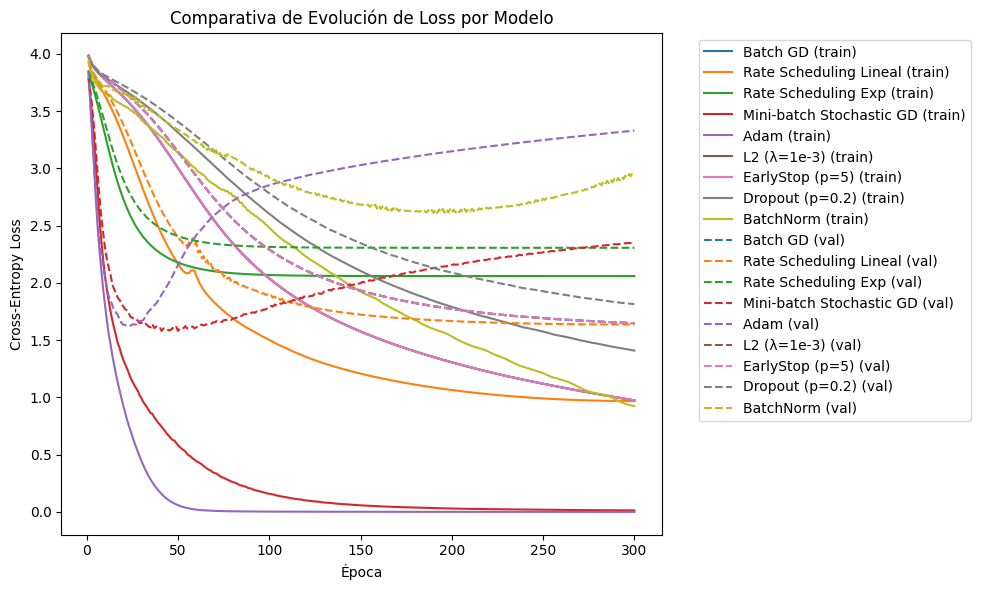

In [ ]:
plt.figure(figsize=(10,5))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']

for i, (name, losses) in enumerate(all_train_losses_optimizers.items()):
    plt.plot(range(1, len(losses)+1), losses, label=f"{name} (train)", color=colors[i])

for i, (name, losses) in enumerate(all_val_losses_optimizers.items()):
    plt.plot(range(1, len(losses)+1), losses, '--', label=f"{name} (val)", color=colors[i])

plt.xlabel("Época")
plt.ylabel("Cross-Entropy Loss")
plt.title("Comparativa de Evolución de Loss por Modelo")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

3.2) prueba greedy

In [ ]:
epochs_m1 = 250

architectures = [
    # Redes ligeras (rápidas de entrenar, menos parámetros)
    [input_size, 32, n_classes],
    [input_size, 64, n_classes],
    [input_size, 64, 32, n_classes],
    
    # Redes de complejidad media (equilibrio)
    [input_size, 100, n_classes],
    [input_size, 128, 64, n_classes],
    [input_size, 100, 50, n_classes],
    [input_size, 100, 80, n_classes],
    [input_size, 64, 64, 32, n_classes],
    
    # Redes más profundas (más capacidad, más lentas)
    [input_size, 150, 80, n_classes],
    [input_size, 512, 256, n_classes],
    [input_size, 128, 64, 32, n_classes],
    [input_size, 256, 128, 64, n_classes],

    # Arquitecturas alternativas con tres capas ocultas
    [input_size, 100, 50, 25, n_classes],
    [input_size, 128, 128, 64, 32, n_classes],
    
    # extra
    # Redes de profundidad media con embudo
    [input_size, 200, 100, 50, n_classes],
    [input_size, 256, 128, 64, 32, n_classes],

    # Redes uniformes de varias capas
    [input_size, 64, 64, 64, 64, n_classes],
    [input_size, 128, 128, 128, n_classes],

    # Bottleneck pronunciado
    [input_size, 128, 32, n_classes],
    [input_size, 64, 16, n_classes],

    # Muy profundas (hasta 6 capas ocultas)
    [input_size, 256, 128, 64, 32, 16, n_classes],
    [input_size, 128, 128, 64, 64, 32, n_classes],

    # Arquitecturas “inversas” (crece luego decrece)
    [input_size, 64, 128, 64, n_classes],
    [input_size, 32, 64, 128, 64, 32, n_classes],
]

# Hiperparámetros base
hyperparams = {
    'optimizer':      ['gd', 'mb', 'adam'],
    'batch_size':     [None, 1, 16, 32, 64, 128, 256],   # None → full‐batch si optimizer!='mb', 
    'learning_rate':  [0.001, 0.005, 0.01, 0.05, 0.1, 0.15, 0.2],
    'l2_lambda':      [0.0, 1e-3, 1e-2, 1e-1],
    'dropout_p':      [0.0, 0.15, 0.2, 0.25, 0.3],
    'use_batchnorm':  [False, True],
    'early_stopping': [False, True],
    'patience':       [5, 10, 15, 20, 30, 50],
    'lr_schedule':    ['none', 'linear', 'exp'],
    'decay_rate':     [0.01, 0.05, 0.1, 0.25],  
    'lr_min':         [0.001, 0.005, 0.01, 0.02] 
}


param_order = [
    'arch',
    'optimizer',
    'arch',
    'early_stopping',
    'patience',
    'arch',
    'learning_rate',
    'batch_size',
    'l2_lambda',
    'dropout_p',
    'use_batchnorm',
    'learning_rate',
    'lr_schedule',
    'decay_rate',   
    'lr_min',   
    'learning_rate',    
    'arch',
]

def greedy_search(architectures, hyperparams, X_train, Y_train_oh, X_val, Y_val_oh, y_train, y_val, epochs=200, seed=SEED):
    """
    Perform greedy hyperparameter search in given order.
    At each step, fix previously chosen values and pick the best for the current parameter.
    Returns a dict with the best configuration and its validation accuracy.
    """
    # Initialize best configuration dict
    best_config = {}
    best_score = -float('inf')

    # Helper to evaluate one config
    def eval_config(config):
        # Unpack config, apply defaults
        arch = config['arch']
        opt = config['optimizer']
        lr = config['learning_rate']
        bs = config['batch_size']
        l2 = config['l2_lambda']
        dp = config['dropout_p']
        bn = config['use_batchnorm']
        es = config['early_stopping']
        pat = config['patience']
        sched = config['lr_schedule']
        decay = config.get('decay_rate', None)
        lr_min = config.get('lr_min', None)

        # Adjust batch_size for optimizer semantics
        if opt in ['gd', 'adam'] and bs is not None:
            return -float('inf')  # invalid combo
        if opt == 'mb' and bs is None:
            bs = 1  # interpret None as pure SGD

        # Build and train network
        nn = NeuralNetwork(
            layer_sizes=arch,
            learning_rate=lr,
            seed=seed,
            optimizer=opt,
            batch_size=bs,
            l2_lambda=l2,
            dropout_p=dp,
            use_batchnorm=bn,
            early_stopping=es,
            patience=pat,
            lr_min=lr_min
        )

        # Schedule
        lr_fn = None
        if sched == 'linear':
            lr_fn = nn.get_linear_schedule(final_lr=lr_min or 0.001, max_epochs=epochs)
        elif sched == 'exp' and decay is not None:
            lr_fn = nn.get_exponential_schedule(decay_rate=decay, final_lr=lr_min)

        # Train
        nn.train_bp(
            X_train, Y_train_oh,
            X_val=X_val, Y_val=Y_val_oh,
            epochs=epochs,
            plot=False,
            lr_schedule=lr_fn,
        )

        # Evaluate on validation
        Yhat_v = nn.forward(X_val, train=False)
        ypred_v = cp.argmax(Yhat_v, axis=0)
        yproba_v = Yhat_v.T
        m_v = Metrics(y_true=y_val, y_pred=ypred_v, y_proba=yproba_v)
        return m_v.accuracy()

    # Iterate over parameters greedily
    for param in param_order:
        best_val = None
        param_best_score = -float('inf')

        # Get candidate values
        if param == 'arch':
            candidates = architectures
        else:
            candidates = hyperparams[param]

        for val in candidates:
            # Skip patience if early_stopping is False and param is patience
            if param == 'patience' and not best_config.get('early_stopping', False):
                break

            # Build test config
            test_config = best_config.copy()
            test_config[param] = val

            # Fill missing for eval
            for p in ['arch', 'optimizer', 'learning_rate', 'batch_size',
                      'l2_lambda', 'dropout_p', 'use_batchnorm',
                      'early_stopping', 'patience', 'lr_schedule', 'decay_rate', 'lr_min']:
                if p not in test_config:
                    # use a default first element
                    if p == 'arch':
                        test_config[p] = architectures[0]
                    else:
                        test_config[p] = hyperparams[p][0]

            score = eval_config(test_config)

            if score > param_best_score:
                param_best_score = score
                best_val = val

        # Fix the best value
        best_config[param] = best_val
        print(f"Best {param}: {best_val} (val_acc={param_best_score:.4f})")

        # Update global best if final param
        if param == param_order[-1]:
            best_score = param_best_score

    return best_config, best_score

# Usage example:
best_cfg, best_acc = greedy_search(architectures, hyperparams,
                                   X_train, Y_train_oh,
                                   X_val, Y_val_oh,
                                   y_train, y_val,
                                   epochs=epochs_m1, seed=SEED)
print("Best config:", best_cfg)
print("Validation accuracy:", best_acc)

Epochs: 100%|██████████| 250/250 [00:03<00:00, 68.82it/s]


Best optimizer: adam (val_acc=0.5650)


Epochs: 100%|██████████| 250/250 [00:05<00:00, 47.02it/s]


Best arch: [784, 512, 256, 49] (val_acc=0.6637)


Epochs:  20%|██        | 50/250 [00:06<00:25,  7.92it/s]


...

Best lr_min: 0.001 (val_acc=0.7075)


Epochs: 100%|██████████| 250/250 [00:31<00:00,  7.85it/s]


Best learning_rate: 0.001 (val_acc=0.7075)


Epochs: 100%|██████████| 250/250 [00:06<00:00, 40.99it/s]


Best arch: [784, 512, 256, 49] (val_acc=0.7075)
Best config: {'optimizer': 'adam', 'arch': [784, 512, 256, 49], 'early_stopping': False, 'patience': None, 'learning_rate': 0.001, 'batch_size': None, 'l2_lambda': 0.1, 'dropout_p': 0.3, 'use_batchnorm': False, 'lr_schedule': 'none', 'decay_rate': 0.01, 'lr_min': 0.001}
Validation accuracy: 0.7075


In [ ]:
for k, v in best_cfg.items():
    print(f"{k}: {v}")

optimizer: adam
arch: [784, 512, 256, 49]
early_stopping: False
patience: None
learning_rate: 0.001
batch_size: None
l2_lambda: 0.1
dropout_p: 0.3
use_batchnorm: False
lr_schedule: none
decay_rate: 0.01
lr_min: 0.001


Epochs: 100%|██████████| 250/250 [00:31<00:00,  7.86it/s]


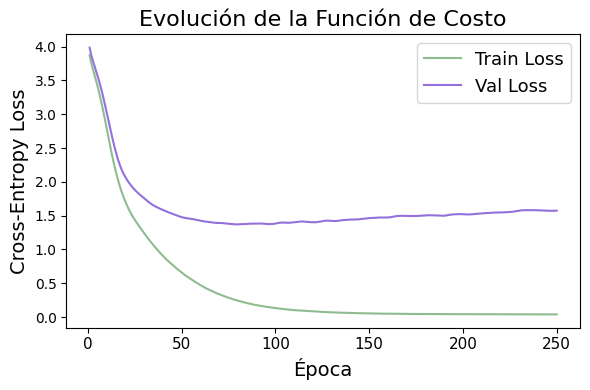

In [ ]:
import cupy as cp

M1 = NeuralNetwork(
    layer_sizes   = best_cfg['arch'],
    learning_rate = best_cfg.get('learning_rate', 0.01),
    seed          = SEED,
    optimizer     = best_cfg.get('optimizer', 'gd'),
    batch_size    = best_cfg.get('batch_size', None),
    l2_lambda     = best_cfg.get('l2_lambda', 0.0),
    dropout_p     = best_cfg.get('dropout_p', 0.0),
    use_batchnorm = best_cfg.get('use_batchnorm', False),
    early_stopping= best_cfg.get('early_stopping', False),
    patience      = best_cfg.get('patience', 5),
)

lr_sched_fn = None
if best_cfg['lr_schedule'] == 'linear':
    lr_sched_fn = M1.get_linear_schedule(
        final_lr=best_cfg.get('lr_min', 0.001),
        max_epochs=epochs_m1
    )
elif best_cfg['lr_schedule'] == 'exp':
    lr_sched_fn = M1.get_exponential_schedule(
        decay_rate=best_cfg['decay_rate']
    )

train_losses_M1, val_losses_M1 = M1.train_bp(
    X_train, Y_train_oh,
    X_val      = X_val,
    Y_val      = Y_val_oh,
    epochs     = epochs_m1,
    plot       = True,
    lr_schedule= lr_sched_fn
)

### Desempeño M1 en Validación
**Accuracy:** **0.7075**  
**Cross-Entropy Loss:** 1.4263  


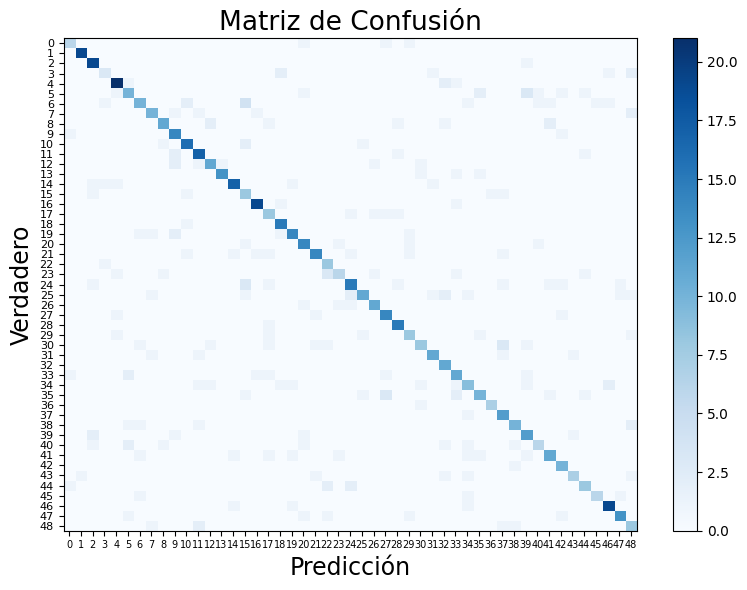

In [ ]:
Yhat_val_M1    = M1.forward(X_val, train=False)          
yproba_val_M1  = Yhat_val_M1.T                  
ypred_val_M1   = cp.argmax(Yhat_val_M1, axis=0) 

met_val_M1 = Metrics(y_true  = y_val, y_pred  = ypred_val_M1, y_proba = yproba_val_M1)
met_val_M1.report_metrics(title="Desempeño M1 en Validación", show_matrix_table=False, plot_matrix_heatmap=True)

again

Epochs: 100%|██████████| 250/250 [01:10<00:00,  3.55it/s]


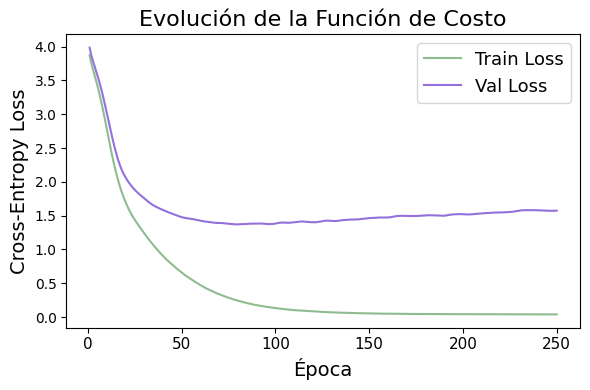

In [73]:
import cupy as cp
epochs_m1 = 250


M1 = NeuralNetwork(
    layer_sizes   = [784, 512, 256, 49],
    learning_rate = 0.001,
    seed          = SEED,
    optimizer     = 'adam',
    batch_size    = None,
    l2_lambda     = 0.1,
    dropout_p     = 0.3,
    use_batchnorm = False,
    early_stopping= False,
    patience      = None
)

# optimizer: adam
# arch: [784, 512, 256, 49]
# early_stopping: False
# patience: None
# learning_rate: 0.001
# batch_size: None
# l2_lambda: 0.1
# dropout_p: 0.3
# use_batchnorm: False
# lr_schedule: none
# decay_rate: 0.01
# lr_min: 0.001


# lr_sched_fn = None
# if best_cfg['lr_schedule'] == 'linear':
#     lr_sched_fn = M1.get_linear_schedule(
#         final_lr=best_cfg.get('lr_min', 0.001),
#         max_epochs=epochs_m1
#     )
# elif best_cfg['lr_schedule'] == 'exp':
#     lr_sched_fn = M1.get_exponential_schedule(
#         decay_rate=best_cfg['decay_rate']
#     )
    
lr_sched_fn = None

# lr_sched_fn = M1.get_exponential_schedule(
#     decay_rate=0.01,
# )

train_losses_M1, val_losses_M1 = M1.train_bp(
    X_train, Y_train_oh,
    X_val      = X_val,
    Y_val      = Y_val_oh,
    epochs     = epochs_m1,
    plot       = True,
    lr_schedule= lr_sched_fn
)

### Desempeño M1 en Validación
**Accuracy:** **0.7075**  
**Cross-Entropy Loss:** 1.4263  


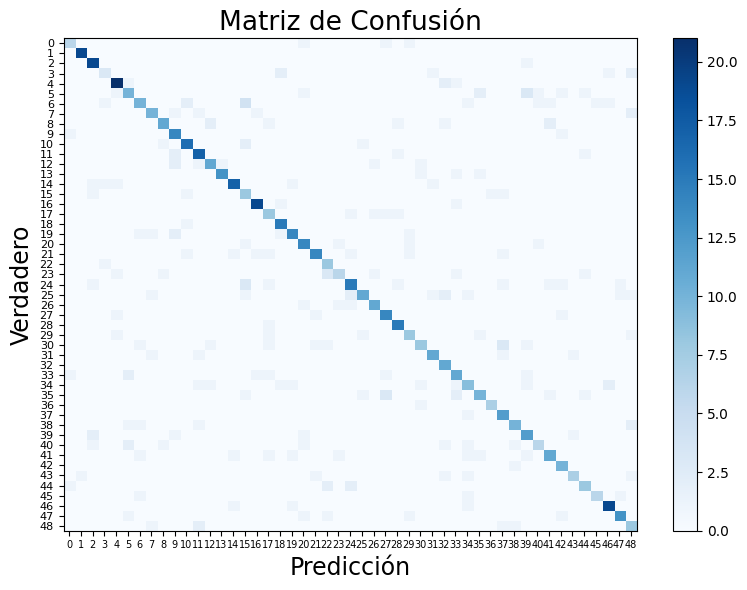

In [74]:
Yhat_val_M1    = M1.forward(X_val, train=False)          
yproba_val_M1  = Yhat_val_M1.T                  
ypred_val_M1   = cp.argmax(Yhat_val_M1, axis=0) 

met_val_M1 = Metrics(y_true  = y_val, y_pred  = ypred_val_M1, y_proba = yproba_val_M1)
met_val_M1.report_metrics(title="Desempeño M1 en Validación", show_matrix_table=False, plot_matrix_heatmap=True)

### `4.` **Desarrollo de una Red Neuronal con PyTorch**


In [37]:
import torch
import torch.nn as nn
import torch.optim as optim
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

#### **M2** - entrenando una red neuronal con la arquitectura y los hiperparámetros hallados

In [19]:
from src.utils import get_dataloader, build_scheduler, train_model

In [ ]:
input_size = X_train.shape[1]
n_classes  = int(cp.max(y_train)) + 1

epochs_M2   = 300
epochs_M3   = 200       

In [28]:
# optimizer: adam
# arch: [784, 512, 256, 49]
# early_stopping: False
# patience: None
# learning_rate: 0.001
# batch_size: None
# l2_lambda: 0.1
# dropout_p: 0.3
# use_batchnorm: False
# lr_schedule: none
# decay_rate: 0.01
# lr_min: 0.001

conf_M2 = {
    'arch':           [784, 512, 256, 49],
    'batch_size':     None,
    'learning_rate':  0.005,
    'l2_lambda':      0.0,
    'dropout_p':      0.3,
    'use_batchnorm':  False,
    'early_stopping': False,
    'patience':       None,
    'optimizer':      'adam',
    'lr_schedule':    'none',
    'decay_rate':     0.01,
    'lr_min':         0.001,
}

In [25]:
from src.Pytorch_models import MLP_M2, MLP_M3

In [31]:
print("Entrenando M2...")
M2, train_losses_M2, val_losses_M2 = train_model(MLP_M2, conf_M2, epochs_M2, X_train, y_train, X_val, y_val)

Entrenando M2...


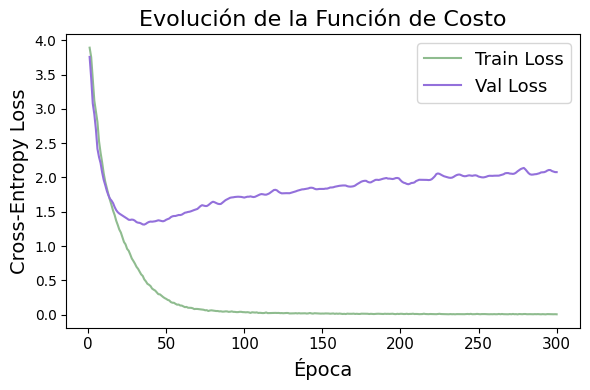

In [33]:
from src.plot import plot_loss
plot_loss(epochs_M2, train_losses_M2, val_losses_M2)

### M2: Métricas finales


### Desempeño M2 en validación
**Accuracy:** **0.7150**  
**Cross-Entropy Loss:** 2.0783  


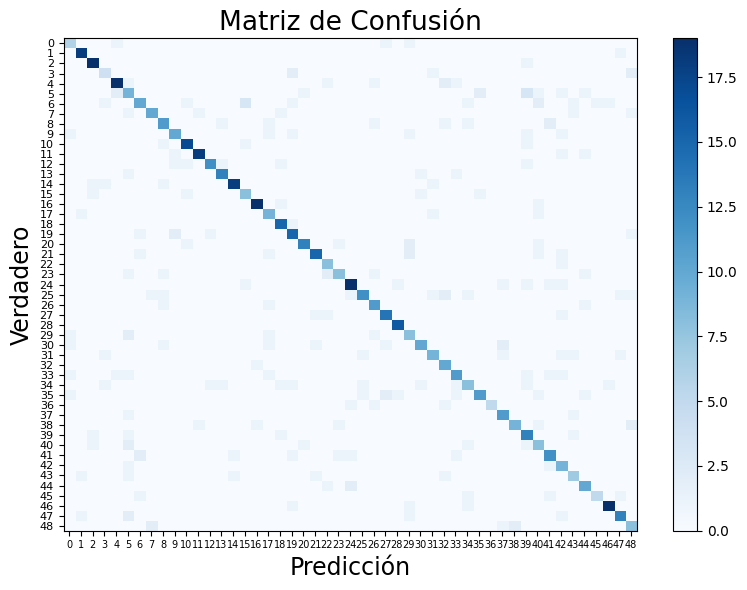

In [32]:
with torch.no_grad():
    Xv_t_M2 = torch.tensor(cp.asnumpy(X_val), dtype=torch.float32)
    logits_M2 = M2(Xv_t_M2)
    probs_M2  = torch.softmax(logits_M2, dim=1)
    preds_M2  = probs_M2.argmax(dim=1)

y_true = y_val
y_pred = cp.array(preds_M2.cpu().numpy())
y_proba= cp.array(probs_M2.cpu().numpy())

print("### M2: Métricas finales")
m2_metrics = Metrics(y_true, y_pred, y_proba)
m2_metrics.report_metrics(title="Desempeño M2 en validación")

#### **M3** - explorando cambios en la cantidad de capas ocultas y unidades ocultas por capa


>>> Explorando arquitecturas para M3...
  [784, 768, 384, 49] -> Acc=0.7275 | TrainLoss=0.0042 | ValLoss=1.9408
  [784, 640, 320, 49] -> Acc=0.7225 | TrainLoss=0.0078 | ValLoss=1.9009
  [784, 512, 256, 128, 49] -> Acc=0.6813 | TrainLoss=0.0332 | ValLoss=2.4292
  [784, 512, 512, 256, 49] -> Acc=0.6887 | TrainLoss=0.0239 | ValLoss=2.4006
  [784, 512, 256, 256, 49] -> Acc=0.6825 | TrainLoss=0.0256 | ValLoss=2.4451
  [784, 384, 256, 128, 49] -> Acc=0.6875 | TrainLoss=0.0413 | ValLoss=2.4103
  [784, 1024, 512, 256, 128, 49] -> Acc=0.6875 | TrainLoss=0.0333 | ValLoss=2.8005
  [784, 512, 256, 128, 64, 49] -> Acc=0.6675 | TrainLoss=0.0652 | ValLoss=2.6767
  [784, 512, 512, 512, 49] -> Acc=0.6763 | TrainLoss=0.0229 | ValLoss=2.7012
  [784, 384, 384, 384, 49] -> Acc=0.6825 | TrainLoss=0.0222 | ValLoss=2.5091
  [784, 512, 128, 49] -> Acc=0.6950 | TrainLoss=0.0236 | ValLoss=1.9698
  [784, 256, 64, 49] -> Acc=0.6825 | TrainLoss=0.0989 | ValLoss=1.9779
  [784, 512, 256, 64, 49] -> Acc=0.6687 | Trai

### Desempeño M3 en Validación
**Accuracy:** **0.7275**  
**Cross-Entropy Loss:** 1.9408  


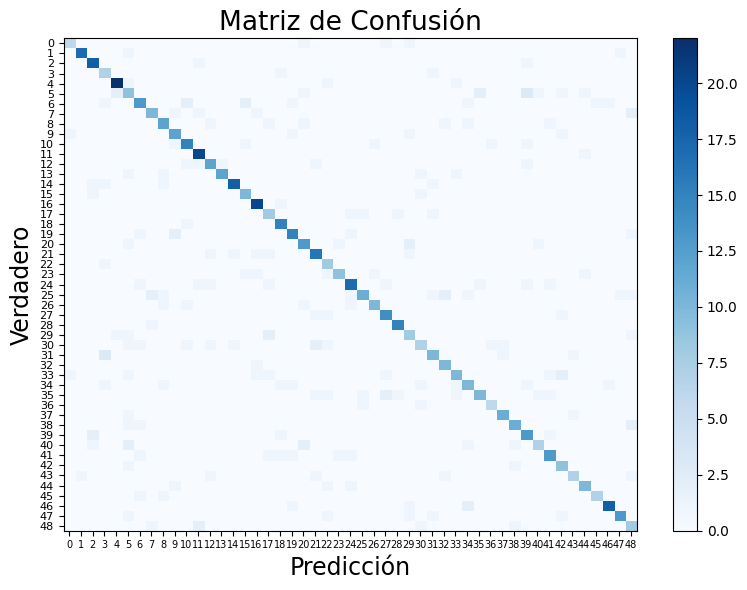

In [61]:

architectures = [
    # Variante con dos capas anchas y una intermedia algo menor
    [input_size, 768, 384,             n_classes],
    [input_size, 640, 320,             n_classes],
    [input_size, 512, 256, 128,        n_classes], 

    # Tres capas anchas antes de la salida
    [input_size, 512, 512, 256,        n_classes],
    [input_size, 512, 256, 256,        n_classes],
    [input_size, 384, 256, 128,        n_classes],

    # Estrategia “embudo progresivo”
    [input_size, 1024, 512, 256, 128,  n_classes],
    [input_size, 512, 256, 128, 64,   n_classes],

    # Capas uniformes pero de mayor tamaño
    [input_size, 512, 512, 512,        n_classes],
    [input_size, 384, 384, 384,        n_classes],

    # Embudo con salto más agresivo
    [input_size, 512, 128,             n_classes],
    [input_size, 256, 64,              n_classes],

    # Añadiendo uno “intermedio estrecho” para forzar características de mayor nivel
    [input_size, 512, 256, 64,         n_classes],
    [input_size, 512, 128, 32,         n_classes],

    # Tres capas uniformes algo más pequeñas
    [input_size, 256, 256, 256,        n_classes],
    [input_size, 320, 320, 320,        n_classes],

    # Arquitectura “piramidal invertida” (crece y luego decrece)
    [input_size, 256, 512, 256,        n_classes],
    [input_size, 128, 256, 128,        n_classes],
]

best_acc_M3   = -1.0
best_arch_M3  = None
best_m3_model = None

print("\n>>> Explorando arquitecturas para M3...")
for arch in architectures:
    # 1) Actualizamos la configuración
    conf = conf_M2.copy()
    conf['arch'] = arch

    # 2) Entrenamos con train_model_pt, que devuelve (modelo, train_losses, val_losses)
    model, train_losses, val_losses = train_model(
        MLP_M3,
        conf    = conf,
        epochs  = epochs_M3,
        X_train = X_train,
        y_train = y_train,
        X_val   = X_val,
        y_val   = y_val,
    )

    # 3) Evaluamos accuracy en validación
    with torch.no_grad():
        Xv_t   = torch.tensor(cp.asnumpy(X_val), dtype=torch.float32).to(device)
        logits = model(Xv_t)
        preds  = logits.argmax(dim=1).cpu().numpy()
        acc    = float((preds == cp.asnumpy(y_val)).mean())

    # 4) Últimas pérdidas de la curva
    last_tr_loss = train_losses[-1]
    last_vl_loss = val_losses[-1]

    print(f"  {arch} -> Acc={acc:.4f} | TrainLoss={last_tr_loss:.4f} | ValLoss={last_vl_loss:.4f}")

    # 5) Guardamos el mejor
    if acc > best_acc_M3:
        best_acc_M3   = acc
        best_arch_M3  = arch
        best_m3_model = model

print(f"\n>> Mejor M3: {best_arch_M3} con Acc={best_acc_M3:.4f}")

# --- Evaluación final del mejor M3 ---
with torch.no_grad():
    Xv_t   = torch.tensor(cp.asnumpy(X_val), dtype=torch.float32).to(device)
    logits = best_m3_model(Xv_t)
    probs  = torch.softmax(logits, dim=1)
    preds  = probs.argmax(dim=1)

y_pred_m3   = cp.array(preds.cpu().numpy())
y_proba_m3  = cp.array(probs.cpu().numpy())
y_true_m3   = y_val

print("\n### M3: Métricas finales")
m3_metrics = Metrics(y_true=y_true_m3, y_pred=y_pred_m3, y_proba=y_proba_m3)
m3_metrics.report_metrics(title="Desempeño M3 en Validación")


In [65]:
M3 = best_m3_model

#### **M4** - buscando una estructura que produzca overfitting


>> Arquitectura M4 elegida: (784, 512, 512, 512, 512, 512, 512, 49)
   train_loss=0.0509, val_loss=19.4216

### M4: Métricas finales


### Desempeño M4 (Over‑fitting)
**Accuracy:** **0.3663**  
**Cross-Entropy Loss:** 11.9415  


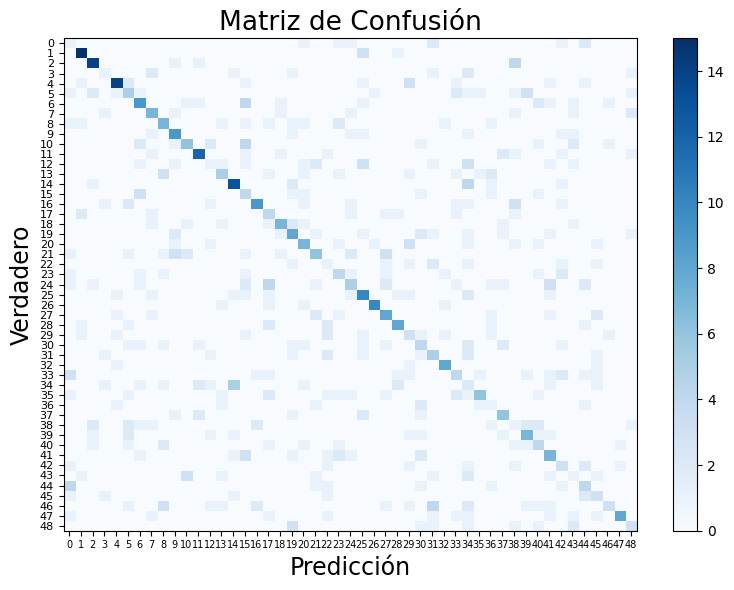

In [75]:
overfit_archs = [
    # Muy profundas y amplias
    [input_size, 2048, 1024, 512, 256, 128, n_classes],
    [input_size, 1024, 1024, 1024, 512, 512, 256, 128, n_classes],
    [input_size, 4096, 2048, 1024, 512, 256, 128, 64, n_classes],
    
    # Muchas capas con “embudo” progresivo
    [input_size, 1024, 512, 256, 128, 64, 32, 16, n_classes],
    [input_size, 2048, 1024, 512, 256, 128, 64, 32, 16, n_classes],
    
    # Anchura extrema en la primera capa
    [input_size, 8192, 4096, 2048, 1024, 512, n_classes],
    [input_size, 4096, 4096, 2048, 1024, 512, 256, n_classes],
    
    # Capas uniformes muy anchas
    [input_size, 2048, 2048, 2048, n_classes],
    [input_size, 1024, 1024, 1024, 1024, n_classes],
    
    # Back‑to‑back gigantes
    [input_size, 512, 512, 512, 512, 512, 512, n_classes],
    [input_size, 256, 512, 1024, 2048, 1024, 512, 256, n_classes],
]

conf_base_m4 = {
    'optimizer':     'gd',
    'batch_size':    None,
    'learning_rate': 0.01,
    'l2_lambda':     0.0,
    'dropout_p':     0.0,
    'use_batchnorm': False,
    'early_stopping': False,
    'patience':       0,
    'lr_schedule':    'none',
}

m4_report = {}
for arch in overfit_archs:
    conf = dict(conf_base_m4, **{'arch': arch})
    # DataLoaders
    train_dl_M4 = get_dataloader(X_train, y_train, conf['batch_size'])
    val_dl_M4   = get_dataloader(X_val,   y_val,   conf['batch_size'])

    M4_final = MLP_M3(conf)  # reutiliza la clase genérica
    criterion = nn.CrossEntropyLoss()
    optimizer_M4 = optim.Adam(
        M4_final.parameters(),
        lr=conf['learning_rate'],
        weight_decay=conf['l2_lambda']
    )

    train_losses_M4, val_losses_M4 = [], []
    for epoch in range(1, epochs_M3 + 1):
        # train
        M4_final.train()
        running_train = 0.0
        for Xb, yb in train_dl_M4:
            optimizer_M4.zero_grad()
            logits_M4 = M4_final(Xb)
            l_M4 = criterion(logits_M4, yb)
            l_M4.backward()
            optimizer_M4.step()
            running_train += l_M4.item() * Xb.size(0)
        train_losses_M4.append(running_train / len(train_dl_M4.dataset))

        # val
        M4_final.eval()
        running_val_M4 = 0.0
        with torch.no_grad():
            for Xb, yb in val_dl_M4:
                logits_M4 = M4_final(Xb)
                l_M4 = criterion(logits_M4, yb)
                running_val_M4 += l_M4.item() * Xb.size(0)
        val_losses_M4.append(running_val_M4 / len(val_dl_M4.dataset))

    m4_report[tuple(arch)] = {
        'model':        M4_final,
        'train_loss':   train_losses_M4[-1],
        'val_loss':     val_losses_M4[-1],
        'train_curve':  train_losses_M4,
        'val_curve':    val_losses_M4
    }

# Selección M4 por mayor gap val_loss - train_loss
best_arch_M4, stats_M4 = max(
    m4_report.items(),
    key=lambda kv: (kv[1]['val_loss'] - kv[1]['train_loss'])
)
best_model_m4 = stats_M4['model']
print(f"\n>> Arquitectura M4 elegida: {best_arch_M4}")
print(f"   train_loss={stats_M4['train_loss']:.4f}, val_loss={stats_M4['val_loss']:.4f}")

# ----------------------------
# 4) Evaluación final de M4 con Metrics
# ----------------------------
best_model_m4.eval()
with torch.no_grad():
    Xv_t = torch.tensor(cp.asnumpy(X_val), dtype=torch.float32)
    logits_M4 = best_model_m4(Xv_t)
    probs_M4  = torch.softmax(logits_M4, dim=1)
    preds_M4  = probs_M4.argmax(dim=1)

y_true_m4  = y_val
y_pred_m4  = cp.array(preds_M4.cpu().numpy())
y_proba_m4 = cp.array(probs_M4.cpu().numpy())

print("\n### M4: Métricas finales")
m4_metrics = Metrics(y_true_m4, y_pred_m4, y_proba_m4)
m4_metrics.report_metrics(title="Desempeño M4 (Over‑fitting)")


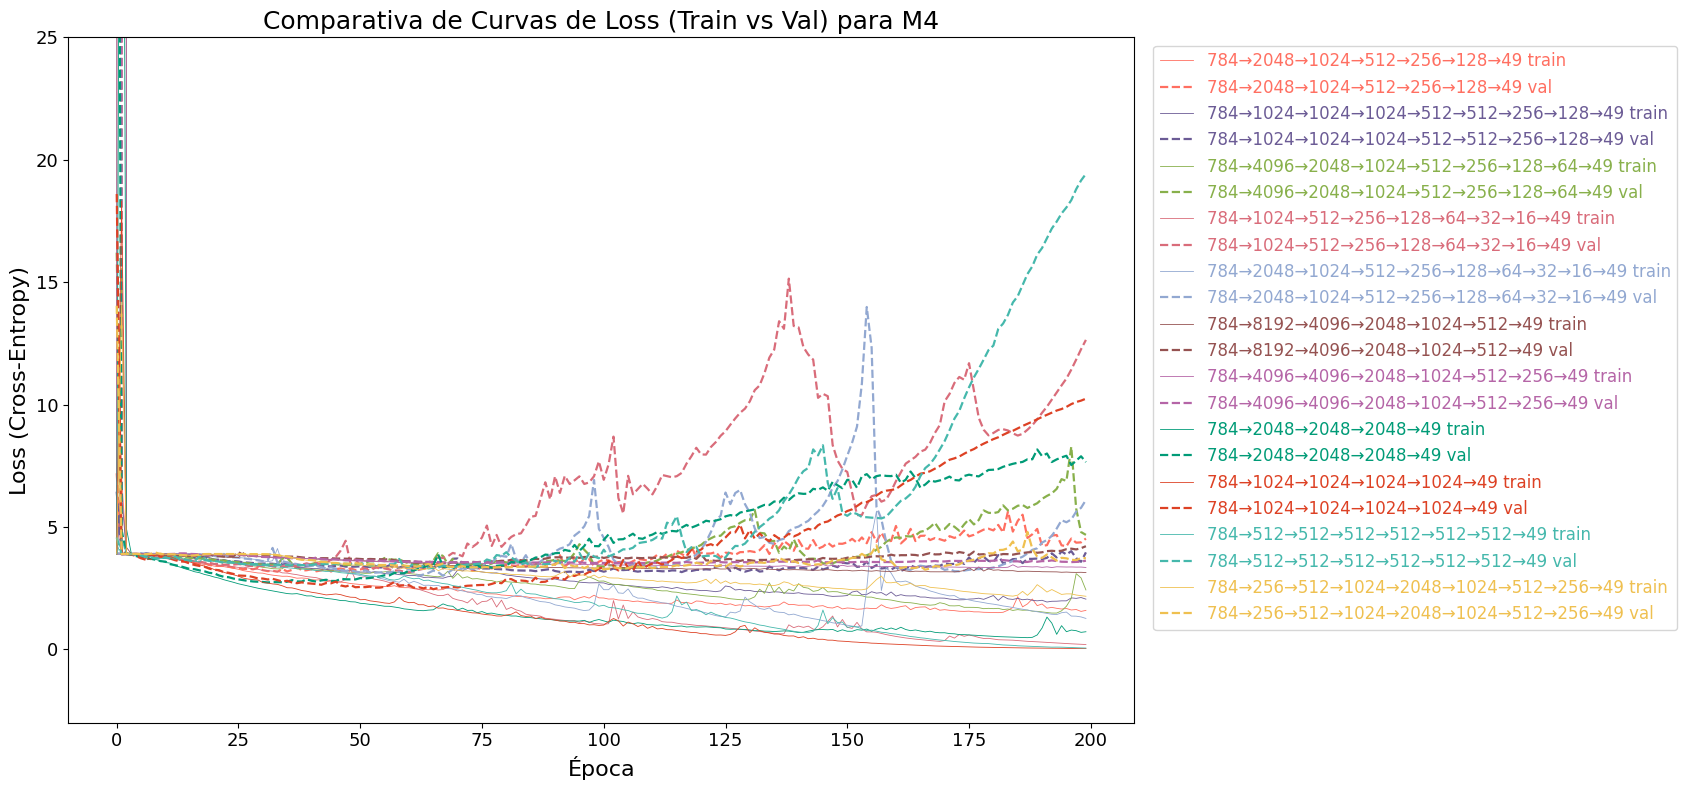

In [76]:
# --- 1) Preparamos el plot ---
plt.figure(figsize=(17, 8))

colors = ['#FF6F61', '#6B5B95', '#88B04B', '#D96C7A', '#92A8D1', 
          '#955251', '#B565A7', '#009B77', '#DD4124', '#45B8AC', 
          '#EFC050']

for i, (arch_tuple, stats_M4) in enumerate(m4_report.items()):
    arch_label = "→".join(str(x) for x in arch_tuple)
    train_curve = stats_M4['train_curve']
    val_curve   = stats_M4['val_curve']
    
    color = colors[i % len(colors)]  # En caso de que haya más arquitecturas que colores
    plt.plot(train_curve, label=f"{arch_label} train", color=color, linewidth=0.6)
    plt.plot(val_curve, '--', label=f"{arch_label} val", color=color, linewidth=1.6)

plt.xlabel("Época", fontsize=16)
plt.ylabel("Loss (Cross-Entropy)", fontsize=16)
plt.title("Comparativa de Curvas de Loss (Train vs Val) para M4", fontsize=18)
plt.ylim(-3, 25)
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)

leg = plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=12)

# colorear cada texto de la leyenda según el color de su línea
for text, line in zip(leg.get_texts(), leg.get_lines()):
    text.set_color(line.get_color())

plt.tight_layout()
# --- 3) Mostrar plot ---
plt.show()


>> Arquitectura M4 elegida: (784, 512, 512, 512, 512, 512, 512, 49)
   train_loss=0.1443, val_loss=12.0064

### M4: Métricas finales


### Desempeño M4 (Over‑fitting)
**Accuracy:** **0.3812**  
**Cross-Entropy Loss:** 9.2106  


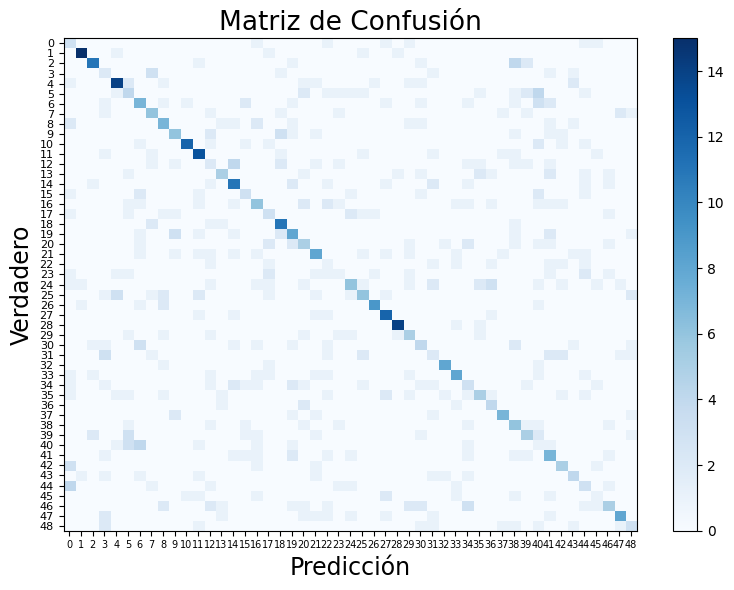

In [94]:
overfit_archs = [
    # Muy profundas y amplias
    [input_size, 2048, 1024, 512, 256, 128, n_classes],
    [input_size, 1024, 1024, 1024, 512, 512, 256, 128, n_classes],
    [input_size, 4096, 2048, 1024, 512, 256, 128, 64, n_classes],
    
    # Muchas capas con “embudo” progresivo
    [input_size, 1024, 512, 256, 128, 64, 32, 16, n_classes],
    [input_size, 2048, 1024, 512, 256, 128, 64, 32, 16, n_classes],
    
    # Anchura extrema en la primera capa
    [input_size, 8192, 4096, 2048, 1024, 512, n_classes],
    [input_size, 4096, 4096, 2048, 1024, 512, 256, n_classes],
    
    # Capas uniformes muy anchas
    [input_size, 2048, 2048, 2048, n_classes],
    [input_size, 1024, 1024, 1024, 1024, n_classes],
    [input_size, 2048, 2048, 2048, 2048, n_classes],
    
    # Back‑to‑back gigantes
    [input_size, 512, 512, 512, 512, 512, 512, n_classes],
    [input_size, 256, 512, 1024, 2048, 1024, 512, 256, n_classes],
]

conf_base_m4 = {
    'optimizer':     'gd',
    'batch_size':    None,
    'learning_rate': 0.01,
    'l2_lambda':     0.0,
    'dropout_p':     0.0,
    'use_batchnorm': False,
    'early_stopping': False,
    'patience':       0,
    'lr_schedule':    'none',
}

m4_report = {}
for arch in overfit_archs:
    conf = dict(conf_base_m4, **{'arch': arch})
    # DataLoaders
    train_dl_M4 = get_dataloader(X_train, y_train, conf['batch_size'])
    val_dl_M4   = get_dataloader(X_val,   y_val,   conf['batch_size'])

    M4_final = MLP_M3(conf)  # reutiliza la clase genérica
    criterion = nn.CrossEntropyLoss()
    optimizer_M4 = optim.Adam(
        M4_final.parameters(),
        lr=conf['learning_rate'],
        weight_decay=conf['l2_lambda']
    )

    train_losses_M4, val_losses_M4 = [], []
    for epoch in range(1, epochs_M3 + 1):
        # train
        M4_final.train()
        running_train = 0.0
        for Xb, yb in train_dl_M4:
            optimizer_M4.zero_grad()
            logits_M4 = M4_final(Xb)
            l_M4 = criterion(logits_M4, yb)
            l_M4.backward()
            optimizer_M4.step()
            running_train += l_M4.item() * Xb.size(0)
        train_losses_M4.append(running_train / len(train_dl_M4.dataset))

        # val
        M4_final.eval()
        running_val_M4 = 0.0
        with torch.no_grad():
            for Xb, yb in val_dl_M4:
                logits_M4 = M4_final(Xb)
                l_M4 = criterion(logits_M4, yb)
                running_val_M4 += l_M4.item() * Xb.size(0)
        val_losses_M4.append(running_val_M4 / len(val_dl_M4.dataset))

    m4_report[tuple(arch)] = {
        'model':        M4_final,
        'train_loss':   train_losses_M4[-1],
        'val_loss':     val_losses_M4[-1],
        'train_curve':  train_losses_M4,
        'val_curve':    val_losses_M4
    }

# Selección M4 por mayor gap val_loss - train_loss
best_arch_M4, stats_M4 = max(
    m4_report.items(),
    key=lambda kv: (kv[1]['val_loss'] - kv[1]['train_loss'])
)
best_model_m4 = stats_M4['model']
print(f"\n>> Arquitectura M4 elegida: {best_arch_M4}")
print(f"   train_loss={stats_M4['train_loss']:.4f}, val_loss={stats_M4['val_loss']:.4f}")

# ----------------------------
# 4) Evaluación final de M4 con Metrics
# ----------------------------
best_model_m4.eval()
with torch.no_grad():
    Xv_t = torch.tensor(cp.asnumpy(X_val), dtype=torch.float32)
    logits_M4 = best_model_m4(Xv_t)
    probs_M4  = torch.softmax(logits_M4, dim=1)
    preds_M4  = probs_M4.argmax(dim=1)

y_true_m4  = y_val
y_pred_m4  = cp.array(preds_M4.cpu().numpy())
y_proba_m4 = cp.array(probs_M4.cpu().numpy())

print("\n### M4: Métricas finales")
m4_metrics = Metrics(y_true_m4, y_pred_m4, y_proba_m4)
m4_metrics.report_metrics(title="Desempeño M4 (Over‑fitting)")


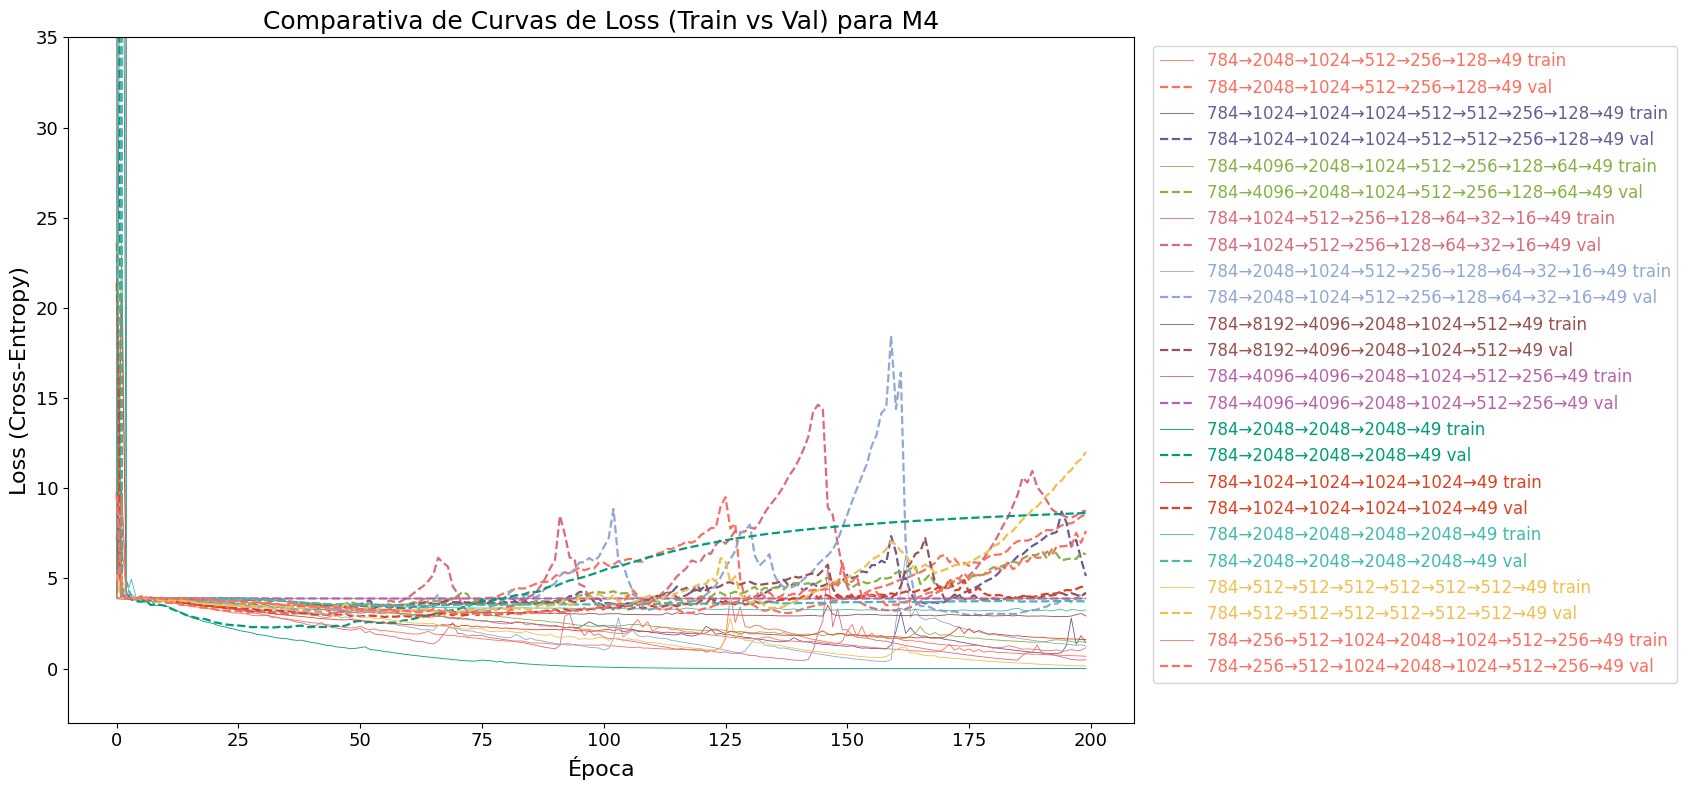

In [95]:
# --- 1) Preparamos el plot ---
plt.figure(figsize=(17, 8))

colors = ['#FF6F61', '#6B5B95', '#88B04B', '#D96C7A', '#92A8D1', 
          '#955251', '#B565A7', '#009B77', '#DD4124', '#45B8AC', 
          '#EFC050']

for i, (arch_tuple, stats_M4) in enumerate(m4_report.items()):
    arch_label = "→".join(str(x) for x in arch_tuple)
    train_curve = stats_M4['train_curve']
    val_curve   = stats_M4['val_curve']
    
    color = colors[i % len(colors)]  # En caso de que haya más arquitecturas que colores
    plt.plot(train_curve, label=f"{arch_label} train", color=color, linewidth=0.6)
    plt.plot(val_curve, '--', label=f"{arch_label} val", color=color, linewidth=1.6)

plt.xlabel("Época", fontsize=16)
plt.ylabel("Loss (Cross-Entropy)", fontsize=16)
plt.title("Comparativa de Curvas de Loss (Train vs Val) para M4", fontsize=18)
plt.ylim(-3, 35)
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)

leg = plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=12)

# colorear cada texto de la leyenda según el color de su línea
for text, line in zip(leg.get_texts(), leg.get_lines()):
    text.set_color(line.get_color())

plt.tight_layout()
# --- 3) Mostrar plot ---
plt.show()

Épocas M4f: 100%|██████████| 2000/2000 [06:14<00:00,  5.34it/s]

Entrenamiento M4f completado: 2000 épocas
Última pérdida train_M4f: 0.5380
Última pérdida val_M4f:   9.5437


### Desempeño final M4f tras 2000 épocas
**Accuracy:** **0.3438**  
**Cross-Entropy Loss:** 7.4190  


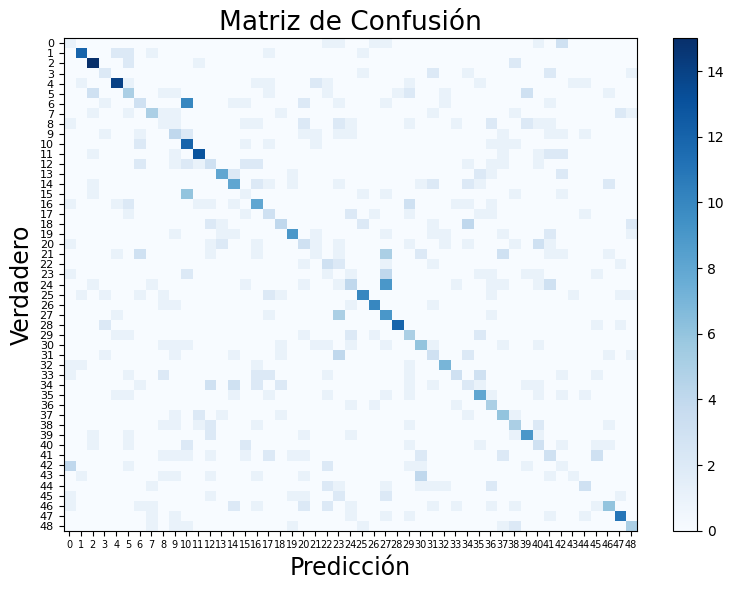

In [ ]:
from tqdm import trange, tqdm

epochs_M4f     = 2000
overfitting_arch = list(best_arch_M4)  

batch_size_M4f = conf_base_m4['batch_size']    # el mismo que usaste antes
lr_M4f         = conf_base_m4['learning_rate'] # idem

# ---------------------------------------------------
# DataLoaders para entrenamiento y validación M4f
# ---------------------------------------------------
train_dl_M4f = get_dataloader(X_train, y_train, batch_size_M4f)
val_dl_M4f   = get_dataloader(X_val,   y_val,   batch_size_M4f)

# ---------------------------------------------------
# Config y modelo M4f con la arquitectura elegida
# ---------------------------------------------------
conf_M4f = {
    'arch':           overfitting_arch,         
    'optimizer':      'gd',              
    'batch_size':     batch_size_M4f,
    'learning_rate':  lr_M4f,
    'l2_lambda':      0.0,
    'dropout_p':      0.0,
    'use_batchnorm':  False,
    'early_stopping': False,
    'patience':       0,
    'lr_schedule':    'none',
}
model_M4f = MLP_M3(conf_M4f)

# ---------------------------------------------------
# Criterio y optimizador M4f
# ---------------------------------------------------
criterion_M4f = nn.CrossEntropyLoss()
optimizer_M4f = optim.Adam(
    model_M4f.parameters(),
    lr=lr_M4f,
    weight_decay=conf_M4f['l2_lambda']
)

# ---------------------------------------------------
# Loop de entrenamiento por 2000 épocas con tqdm
# ---------------------------------------------------
train_losses_M4f, val_losses_M4f = [], []

for epoch in trange(1, epochs_M4f + 1, desc="Épocas M4f"):
    # Modo entrenamiento
    model_M4f.train()
    running_tr_M4f = 0.0
    for Xb, yb in train_dl_M4f:
        optimizer_M4f.zero_grad()
        logits_M4f = model_M4f(Xb)
        loss_M4f   = criterion_M4f(logits_M4f, yb)
        loss_M4f.backward()
        optimizer_M4f.step()
        running_tr_M4f += loss_M4f.item() * Xb.size(0)
    train_losses_M4f.append(running_tr_M4f / len(train_dl_M4f.dataset))

    # Modo evaluación (validación)
    model_M4f.eval()
    running_val_M4f = 0.0
    with torch.no_grad():
        for Xb, yb in val_dl_M4f:
            logits_M4f = model_M4f(Xb)
            loss_M4f   = criterion_M4f(logits_M4f, yb)
            running_val_M4f += loss_M4f.item() * Xb.size(0)
    val_losses_M4f.append(running_val_M4f / len(val_dl_M4f.dataset))

# ---------------------------------------------------
# Resultados finales M4f
# ---------------------------------------------------
print(f"Entrenamiento M4f completado: {epochs_M4f} épocas")
print(f"Última pérdida train_M4f: {train_losses_M4f[-1]:.4f}")
print(f"Última pérdida val_M4f:   {val_losses_M4f[-1]:.4f}")

# Recalcular métricas finales M4f
model_M4f.eval()
with torch.no_grad():
    Xv_t_M4f = torch.tensor(cp.asnumpy(X_val), dtype=torch.float32)
    logits_M4f = model_M4f(Xv_t_M4f)
    probs_M4f  = torch.softmax(logits_M4f, dim=1)
    preds_M4f  = probs_M4f.argmax(dim=1)

y_true_M4f  = y_val
y_pred_M4f  = cp.array(preds_M4f.cpu().numpy())
y_proba_M4f = cp.array(probs_M4f.cpu().numpy())

m4f_metrics = Metrics(y_true_M4f, y_pred_M4f, y_proba_M4f)
m4f_metrics.report_metrics(title="Desempeño final M4 después de 2000 épocas")

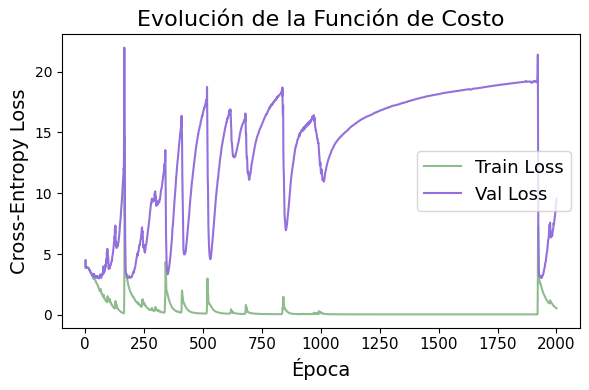

In [97]:
from src.plot import plot_loss
plot_loss(epochs_M4f, train_losses_M4f, val_losses_M4f)

otro con losses guardadas

In [ ]:
# ----------------------------
# Configuración M4f final
# ----------------------------
conf_M4f = {
    'arch':           overfitting_arch,         
    'optimizer':      'gd',              
    'batch_size':     batch_size_M4f,
    'learning_rate':  lr_M4f,
    'l2_lambda':      0.0,
    'dropout_p':      0.0,
    'use_batchnorm':  False,
    'early_stopping': False,
    'patience':       0,
    'lr_schedule':    'none',
}

epochs_M4f = 2000

# ----------------------------
# 1) Preparar DataLoaders
# ----------------------------
train_dl_M4f = get_dataloader(X_train, y_train, conf_M4f['batch_size'])
val_dl_M4f   = get_dataloader(X_val,   y_val,   conf_M4f['batch_size'])
n_batches_M4f = len(train_dl_M4f)

# ----------------------------
# 2) Construir modelo y optimizadores
# ----------------------------
model_M4f     = MLP_M2(conf_M4f)           # reutilizamos MLP_M2
criterion_M4f = nn.CrossEntropyLoss()
optimizer_M4f = optim.SGD(
    model_M4f.parameters(),
    lr=conf_M4f['learning_rate'],
    weight_decay=conf_M4f['l2_lambda']
)
scheduler_M4f = build_scheduler(optimizer_M4f,
                                conf_M4f['lr_schedule'],
                                conf_M4f['patience'],
                                n_batches_M4f)

# ----------------------------
# 3) Entrenamiento con captura de pérdidas
# ----------------------------
train_losses_M4f, val_losses_M4f = [], []
best_val_loss_M4f = float('inf')
wait_M4f = 0
best_state_M4f = None

for epoch in range(1, epochs_M4f + 1):
    # train
    model_M4f.train()
    running_train_M4f = 0.0
    for Xb, yb in train_dl_M4f:
        optimizer_M4f.zero_grad()
        logits_M4f = model_M4f(Xb)
        loss_M4f = criterion_M4f(logits_M4f, yb)
        loss_M4f.backward()
        optimizer_M4f.step()
        if scheduler_M4f:
            scheduler_M4f.step()
        running_train_M4f += loss_M4f.item() * Xb.size(0)
    train_losses_M4f.append(running_train_M4f / len(train_dl_M4f.dataset))

    # val
    model_M4f.eval()
    running_val_M4f = 0.0
    with torch.no_grad():
        for Xb, yb in val_dl_M4f:
            logits_M4f = model_M4f(Xb)
            loss_M4f = criterion_M4f(logits_M4f, yb)
            running_val_M4f += loss_M4f.item() * Xb.size(0)
    val_loss_M4f = running_val_M4f / len(val_dl_M4f.dataset)
    val_losses_M4f.append(val_loss_M4f)

    # early stopping
    if val_loss_M4f < best_val_loss_M4f:
        best_val_loss_M4f = val_loss_M4f
        wait_M4f = 0
        best_state_M4f = model_M4f.state_dict()
    else:
        wait_M4f += 1
        if conf_M4f['early_stopping'] and wait_M4f >= conf_M4f['patience']:
            print(f"Early stopping en época {epoch}")
            break

# restaurar mejor estado
if best_state_M4f is not None:
    model_M4f.load_state_dict(best_state_M4f)



otro

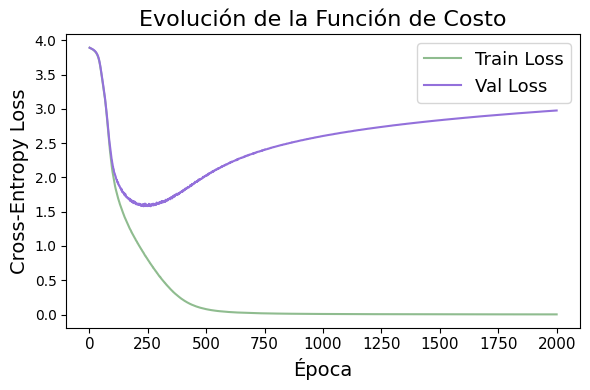

In [ ]:
from src.plot import plot_loss
plot_loss(epochs_M4f, train_losses_M4, val_losses_M4)

#### 4.3) Comparación entre **M0**, **M1**, **M2**, **M3** y **M4**

In [156]:
from IPython.display import display, Markdown
import cupy as cp
import torch

# ----------------------------
# 1) Predicciones sobre X_test con CuPy
# ----------------------------
# M0 (implementación propia, devuelve NumPy)
Yhat0_np   = M0.forward(X_test, train = False)                   # (n_classes, m_test) NumPy
Yhat0_cp   = cp.array(Yhat0_np)                   # transforma a CuPy
yproba_0   = Yhat0_cp.T                           # (m_test, n_classes)
ypred_0    = cp.argmax(Yhat0_cp, axis=0)          # (m_test,)

# M1 (mejor arquitectura propia)
Yhat1_np   = M1.forward(X_test, train = False)
Yhat1_cp   = cp.array(Yhat1_np)
yproba_1   = Yhat1_cp.T
ypred_1    = cp.argmax(Yhat1_cp, axis=0)

# M2 (PyTorch misma arquitectura propia)
with torch.no_grad():
    Xt2      = torch.tensor(cp.asnumpy(X_test), dtype=torch.float32)
    logits2  = M2(Xt2)
    probs2   = torch.softmax(logits2, dim=1)
    yproba_2 = cp.array(probs2.cpu().numpy())
    ypred_2  = cp.array(probs2.argmax(dim=1).cpu().numpy())

# M3 (mejor arquitectura PyTorch)
with torch.no_grad():
    Xt3      = torch.tensor(cp.asnumpy(X_test), dtype=torch.float32)
    logits3  = M3(Xt3)
    probs3   = torch.softmax(logits3, dim=1)
    yproba_3 = cp.array(probs3.cpu().numpy())
    ypred_3  = cp.array(probs3.argmax(dim=1).cpu().numpy())

# M4f (arquitectura over-fitting)
with torch.no_grad():
    Xt4      = torch.tensor(cp.asnumpy(X_test), dtype=torch.float32)
    logits4  = model_M4f(Xt4)
    probs4   = torch.softmax(logits4, dim=1)
    yproba_4 = cp.array(probs4.cpu().numpy())
    ypred_4  = cp.array(probs4.argmax(dim=1).cpu().numpy())

# ----------------------------
# 2) Cálculo de métricas con CuPy
# ----------------------------
met0 = Metrics(y_true=y_test, y_pred=ypred_0, y_proba=yproba_0)
acc0, ce0 = met0.accuracy(), met0.cross_entropy()

met1 = Metrics(y_true=y_test, y_pred=ypred_1, y_proba=yproba_1)
acc1, ce1 = met1.accuracy(), met1.cross_entropy()

met2 = Metrics(y_true=y_test, y_pred=ypred_2, y_proba=yproba_2)
acc2, ce2 = met2.accuracy(), met2.cross_entropy()

met3 = Metrics(y_true=y_test, y_pred=ypred_3, y_proba=yproba_3)
acc3, ce3 = met3.accuracy(), met3.cross_entropy()

met4 = Metrics(y_true=y_test, y_pred=ypred_4, y_proba=yproba_4)
acc4, ce4 = met4.accuracy(), met4.cross_entropy()

# ----------------------------
# 3) Montar y mostrar tabla Markdown
# ----------------------------
header = "|Modelo|Accuracy|Cross-Entropy|\n"
sep    = "|" + "---|"*3 + "\n"
rows = "\n".join([
    f"|M0 (base propia)|{acc0:.4f}|{ce0:.4f}|",
    f"|M1 (mejor propia)|{acc1:.4f}|{ce1:.4f}|",
    f"|M2 (PyTorch misma)|{acc2:.4f}|{ce2:.4f}|",
    f"|M3 (mejor PyTorch)|{acc3:.4f}|{ce3:.4f}|",
    f"|M4f (over-fit)|{acc4:.4f}|{ce4:.4f}|",
])
display(Markdown("## Comparativa en Test"))
display(Markdown(header + sep + rows))


## Comparativa en Test

|Modelo|Accuracy|Cross-Entropy|
|---|---|---|
|M0 (base propia)|0.6020|2.0131|
|M1 (mejor propia)|0.6770|1.5798|
|M2 (PyTorch misma)|0.6900|2.1878|
|M3 (mejor PyTorch)|0.7060|2.0791|
|M4f (over-fit)|0.4140|13.5703|

In [ ]:
# M0
Yhat0_np   = M0.forward(X_test, train = False)                   # (n_classes, m_test) NumPy
Yhat0_cp   = cp.array(Yhat0_np)                   # transforma a CuPy
yproba_0   = Yhat0_cp.T                           # (m_test, n_classes)
ypred_0    = cp.argmax(Yhat0_cp, axis=0)          # (m_test,)

# M1
Yhat1_np   = M1.forward(X_test, train = False)
Yhat1_cp   = cp.array(Yhat1_np)
yproba_1   = Yhat1_cp.T
ypred_1    = cp.argmax(Yhat1_cp, axis=0)

# M2
with torch.no_grad():
    Xt2      = torch.tensor(cp.asnumpy(X_test), dtype=torch.float32)
    logits2  = M2(Xt2)
    probs2   = torch.softmax(logits2, dim=1)
    yproba_2 = cp.array(probs2.cpu().numpy())
    ypred_2  = cp.array(probs2.argmax(dim=1).cpu().numpy())

# M3
with torch.no_grad():
    Xt3      = torch.tensor(cp.asnumpy(X_test), dtype=torch.float32)
    logits3  = M3(Xt3)
    probs3   = torch.softmax(logits3, dim=1)
    yproba_3 = cp.array(probs3.cpu().numpy())
    ypred_3  = cp.array(probs3.argmax(dim=1).cpu().numpy())

# M4
with torch.no_grad():
    Xt4      = torch.tensor(cp.asnumpy(X_test), dtype=torch.float32)
    logits4  = model_M4f(Xt4)
    probs4   = torch.softmax(logits4, dim=1)
    yproba_4 = cp.array(probs4.cpu().numpy())
    ypred_4  = cp.array(probs4.argmax(dim=1).cpu().numpy())


met0 = Metrics(y_true=y_test, y_pred=ypred_0, y_proba=yproba_0)
acc0, ce0 = met0.accuracy(), met0.cross_entropy()

met1 = Metrics(y_true=y_test, y_pred=ypred_1, y_proba=yproba_1)
acc1, ce1 = met1.accuracy(), met1.cross_entropy()

met2 = Metrics(y_true=y_test, y_pred=ypred_2, y_proba=yproba_2)
acc2, ce2 = met2.accuracy(), met2.cross_entropy()

met3 = Metrics(y_true=y_test, y_pred=ypred_3, y_proba=yproba_3)
acc3, ce3 = met3.accuracy(), met3.cross_entropy()

met4 = Metrics(y_true=y_test, y_pred=ypred_4, y_proba=yproba_4)
acc4, ce4 = met4.accuracy(), met4.cross_entropy()


header = "|Modelo|Accuracy|Cross-Entropy|\n"
sep    = "|" + "---|"*3 + "\n"
rows = "\n".join([
    f"|M0 (base propia)|{acc0:.4f}|{ce0:.4f}|",
    f"|M1 (mejor propia)|{acc1:.4f}|{ce1:.4f}|",
    f"|M2 (PyTorch misma)|{acc2:.4f}|{ce2:.4f}|",
    f"|M3 (mejor PyTorch)|{acc3:.4f}|{ce3:.4f}|",
    f"|M4f (over-fit)|{acc4:.4f}|{ce4:.4f}|",
])
display(Markdown("## Comparativa en Test"))
display(Markdown(header + sep + rows))

## Comparativa en Test

|Modelo|Accuracy|Cross-Entropy|
|---|---|---|
|M0 (base propia)|0.6020|1.9409|
|M1 (mejor propia)|0.6770|1.5798|
|M2 (PyTorch misma)|0.6900|2.2352|
|M3 (mejor PyTorch)|0.7060|2.0791|
|M4f (over-fit)|0.3300|8.2271|

### `5.` **Desafío**

In [ ]:
import pandas as pd

X_comp = cp.load('data/X_COMP.npy')    
X_comp = X_comp / 255.0    

In [ ]:
best_model = M3

X_comp_t = torch.tensor(cp.asnumpy(X_comp), dtype=torch.float32)

best_model.eval()

with torch.no_grad():
    logits_M4 = best_model(X_comp_t)
    probs_M4  = torch.softmax(logits_M4, dim=1)

# CuPy -> pandas
probs_cp = cp.array(probs_M4.cpu().numpy())
col_names = [f"Clase_{i}" for i in range(probs_cp.shape[1])]
df = pd.DataFrame(probs_cp.get(), columns=col_names)

df.to_csv('Tissera_AnaPaula_predicciones.csv', index=False)
print("Tissera_AnaPaula_predicciones.csv generado")

Tissera_AnaPaula_predicciones.csv generado
